In [1]:
import sys
sys.path.insert(0, '.')
print('sys.path adjusted:', sys.path[0])


sys.path adjusted: .


# EVRP XAI Case Study

This notebook demonstrates how to use `src/xai/attribution.py` to explain agent decisions, visualize route importances, and run what-if scenarios. The notebook uses a synthetic 'mid-city' scenario with 50 nodes for demonstration.

In [2]:
# Basic imports
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from src.xai.attribution import perturbation_importance, approximate_shapley, plot_route_importance, what_if_run
from src.framework import EnvFactory, AgentFactory

print('Imports OK')

Imports OK


In [3]:
# Create synthetic mid-city scenario (50 nodes)
num_nodes = 50
coords = np.random.RandomState(123).uniform(0, 100, size=(num_nodes, 2))
G = nx.complete_graph(num_nodes)
for i in G.nodes():
    G.nodes[i]['pos'] = tuple(coords[i])

# Dummy route (nearest-neighbor from node 0)
route = [0]

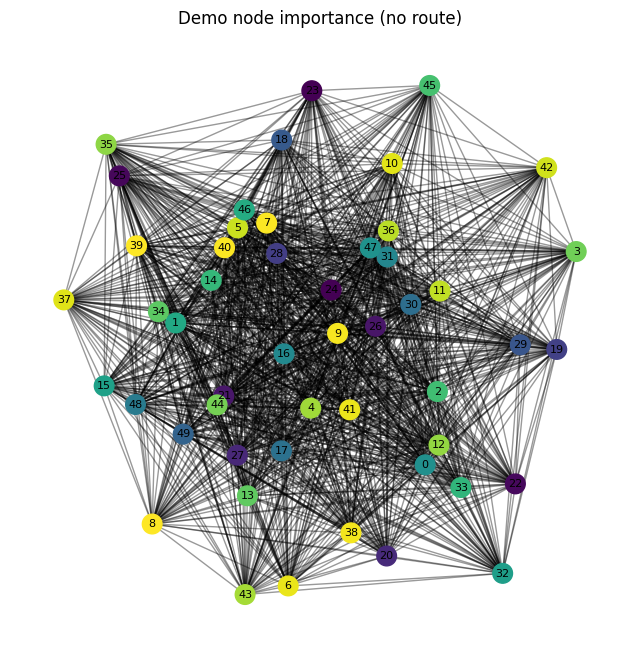

In [4]:
# Draw base route (placeholder) and importance heatmap example
# Create a fake importance map for demonstration
node_imp = {i: np.sin(i / 5.0) for i in G.nodes()}
ax = plot_route_importance(G, route, node_importance=node_imp)
plt.title('Demo node importance (no route)')
plt.show()

## What-if analysis
Modify battery capacity or charger counts and re-run policy to observe changes in route and charges. Use `what_if_run` with your `EnvFactory` and agent action function.

In [5]:
# Example: placeholder what-if (requires a real agent and env).
def dummy_agent_action_fn(env, obs):
    # pick first valid action
    mask = np.asarray(obs['valid_actions_mask']).astype(bool)
    valid = np.where(mask)[0]
    return int(valid[0]) if len(valid) > 0 else 0

def modifier_increase_battery(scn):
    scn['max_battery'] = scn.get('max_battery', 500.0) * 1.5
    return scn

# This is illustrative: replace EnvFactory.create with your env constructor if needed
# res = what_if_run(EnvFactory.create, dummy_agent_action_fn, {'num_customers':20,'num_chargers':3,'max_battery':500.0}, modifier_increase_battery)
# print(res)
print('What-if placeholder ready')

What-if placeholder ready
